# Notebook for spatial plots

### Import statements

In [1]:
from netCDF4 import Dataset
import wrf
from wrf import getvar, ALL_TIMES, latlon_coords, CoordPair, vertcross, to_np, interpline
import xarray as xr
import numpy as np
import cartopy.crs as crs
from matplotlib.cm import get_cmap
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm 
import matplotlib as mpl
import pandas as pd
from matplotlib import gridspec

### Defining functions

In [4]:
def match_tti(dataset, date, time): #match time to index
    timelist = wrf.extract_times(dataset, timeidx = ALL_TIMES)
    if len(time) ==7:
        timestr = str(date)+"T0"+str(time)+".000000000"
    if len(time) ==8:
        timestr = str(date)+"T"+str(time)+".000000000"
    if isinstance(dataset, list):
        for file in dataset:
            if timestr in str(wrf.extract_times(file, timeidx = ALL_TIMES)):
                file_num = dataset.index(file)
    else:
        file_num = ''
    for idx, t in enumerate(timelist):
        if timestr == str(t):
            ind = idx
            break
    else:
        return print('Time not in dataset')
    return(ind,file_num,f'timeidx: {ind} for {t}')

# print(match_tti(data_defurb,"2018-12-19","13:00:00"))#example

def utc_to_aest(timestr):
    utc = pd.Timestamp(timestr,tz='UTC')
    aus = utc.tz_convert(tz='Australia/Sydney')
    date = str(aus).split(' ')[0]
    time = str(aus).split(' ')[1][:8]
    wrfstr = date+"T"+time+".000000000"
    aest = time+' '+date
    return(wrfstr,aest,f'AEST is {time} {date}')

# print(utc_to_aest('2018-12-18T02:00:00.000000000')[1]) #example

def get_indexes(caselist,start,end): #start date (sd), start hour (sh), end date (ed) and end hour (eh)
    indl = []
    for case in caselist:
        inds = match_tti(case, aest_to_utc(start[0],start[1])[1][0], aest_to_utc(start[0],start[1])[1][1])[0]
        inde = match_tti(case, aest_to_utc(end[0],end[1])[1][0], aest_to_utc(end[0],end[1])[1][1])[0]
        indl.append([inds,inde])
    return indl

def aest_to_utc(date,time):
    datetime = f'{date} {time}'
    austime = pd.Timestamp(datetime,tz='Australia/Sydney')
    utctime = austime.tz_convert(tz='UTC')
    udate = str(utctime).split(' ')[0]
    utime = str(utctime).split(' ')[1][:8] 
    wrfstr = udate+"T"+utime+".000000000"  
    return(wrfstr,[udate, utime])
# print(aest_to_utc('2018-12-18','13:00:00')[0]) #example


def percentcov(var):
    land = wrf.getvar(data_17_gr, 'LU_INDEX', timeidx=8, method='cat')
    urbland = np.where(land <= 49, 0, land)
    urb = np.where(land <= 49, 0, land)
    variable = np.where(var == 49, 0, var)
    urb[0:140, 0:200] = 0 # area below Sydney
    urb[0:289, 0:150] = 0 # left of Sydney
    urb[205:289, 0:279] = 0 # left of Sydney
    metarea = np.count_nonzero(urb)
    totarea = len(urbland)*len(urbland[0])
    urbarea = np.count_nonzero(urbland)
    vararea = np.count_nonzero(var)
    urbvar = np.where(urbland == 0, 0, var)
    metvar = np.where(urb == 0, 0, var)
    urbvararea = np.count_nonzero(urbvar)
    metvararea = np.count_nonzero(metvar)
    return({'Urban area': [f'{round(float(urbvararea/urbarea)*100,1)}%',round(float(urbvar.max()),2)],
            'Sydney metropolitan': [f'{round(float(metvararea/metarea)*100,1)}%',round(float(metvar.max()),2)],
            'Total domain': [f'{round(float(vararea/totarea)*100,1)}%', round(float(variable.max()),2)]})

# returns percentage and maximum value

def hailsizes(hail):
    bighail = np.where(hail <= 2, 0, hail)
    largehail = np.where(bighail > 5, 0, bighail)
    gianthail = np.where(hail <= 5, 0, hail)
    return [f'Large hail  {percentcov(largehail)}', f'Giant hail  {percentcov(gianthail)}']

grid = [Dataset('lu_index_gr.nc')]

def gr_coastline():
    grland = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat')
    wat = np.where(grland != 17, 0, grland)
    water = np.where(wat == 17, 1, wat)
    water[0:290, 0:130] = 0 
    water[26:290, 0:156] = 0
    water[26:33, 0:157] = 0 
    water[25:30, 0:156] = 0
    water[47:49, 0:167] = 0
    water[80:160, 0:175] = 0
    water[95:160, 0:177] = 0
    water[120:190, 0:182] = 0
    water[132:190, 0:186] = 0
    water[150:154, 0:203] = 0
    water[168:172, 0:214] = 0
    water[190:210, 0:215] = 0
    water[192:200, 0:218] = 0
    water[210:290, 0:225] = 0
    water[220:290, 0:233] = 0
    water[225:290, 0:236] = 0
    water[230:290, 0:237] = 0
    water[232:290, 0:241] = 0
    water[229:290, 0:237] = 0
    water[242:290, 0:245] = 0
    water[251:290, 0:250] = 0
    water[278:290, 0:266] = 0
    return water

def urb_outline():
    grland = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat')
    urb = np.where(grland <= 49, 0, grland) #set everything that isn't urban to zero
    uniurb = np.where(urb >= 49, 1, urb) #make urban area uniform
    return uniurb

default = [Dataset('lu_index_def.nc')]

def def_urb_outline():
    defland = wrf.getvar(default, 'LU_INDEX', timeidx=0, method='cat')
    urb = np.where(defland != 13, 0, defland) #set everything that isn't urban to zero
    uniurb = np.where(urb == 13, 1, urb) #make urban area uniform
    return uniurb


# Plots

### Ensemble-averaged surface hail

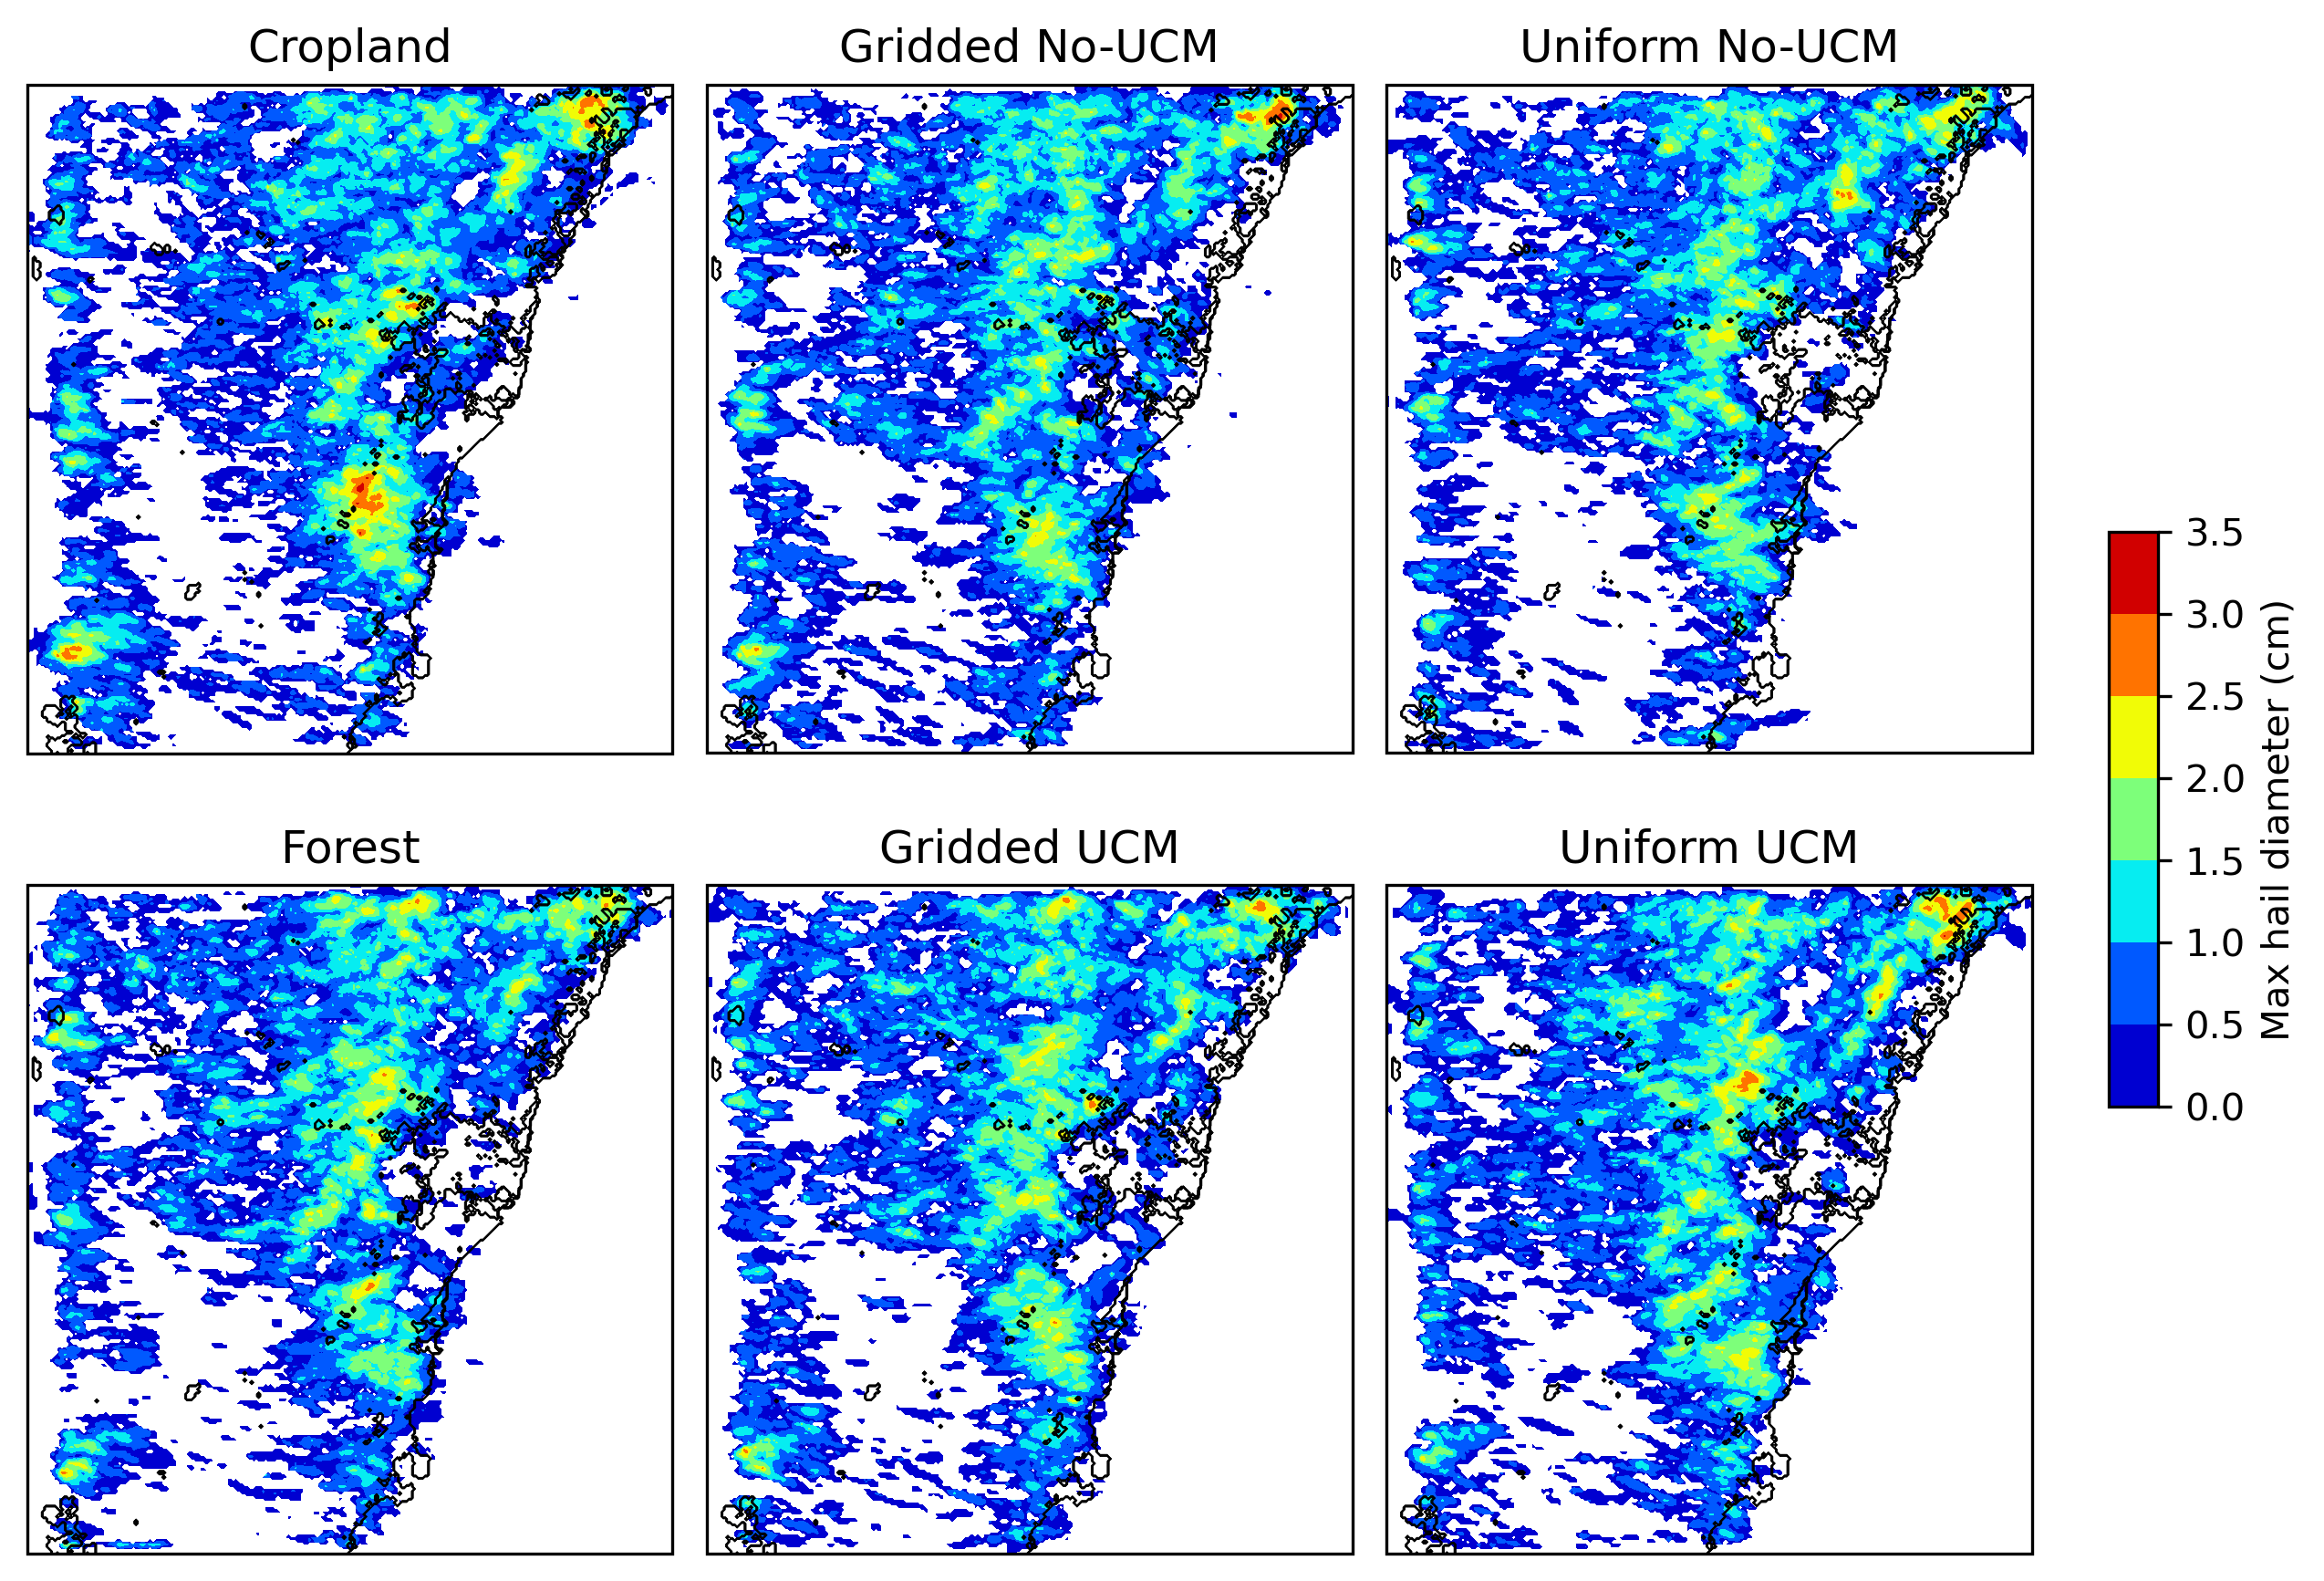

In [9]:
date = '17_2020'
avg_crop = xr.open_dataset(f'WRF_saved_variables/Avghail_crop_{date}.nc')['HAIL_MAXK1']
avg_nat = xr.open_dataset(f'WRF_saved_variables/Avghail_nat_{date}.nc')['HAIL_MAXK1']
avg_gr = xr.open_dataset(f'WRF_saved_variables/Avghail_gr_{date}.nc')['HAIL_MAXK1']
avg_grurb = xr.open_dataset(f'WRF_saved_variables/Avghail_grurb_{date}.nc')['HAIL_MAXK1']
avg_def = xr.open_dataset(f'WRF_saved_variables/Avghail_def_{date}.nc')['HAIL_MAXK1']
avg_defurb = xr.open_dataset(f'WRF_saved_variables/Avghail_defurb_{date}.nc')['HAIL_MAXK1']

en_avgs = [avg_crop, avg_gr, avg_def, avg_nat, avg_grurb, avg_defurb]
names = ['Cropland', 'Gridded No-UCM', 'Uniform No-UCM', 'Forest', 'Gridded UCM','Uniform UCM' ]

date_dict = {'13_2024':'13/02/2024', '17_2020':'17/12/2020', '18_2017':'18/02/2017', '20_2018':'20/12/2018'}
plot_date = date_dict[date]

max_list = []
for dataset in en_avgs:
    max_list.append(dataset.max())
max_hail_size = (np.ceil(max(max_list)*2)/2).values

hal = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat') # for metadata

lats, lons = wrf.latlon_coords(hal)
cart_proj = wrf.get_cartopy(hal)

fig = plt.figure(figsize=(12,6), dpi=300)

gs = gridspec.GridSpec(nrows=2, ncols=8, figure=fig)

ax1 = fig.add_subplot(gs[0, 1:3], projection=cart_proj)
ax2 = fig.add_subplot(gs[0, 3:5], projection=cart_proj)
ax3 = fig.add_subplot(gs[0, 5:7], projection=cart_proj)
ax4 = fig.add_subplot(gs[1, 1:3], projection=cart_proj)
ax5 = fig.add_subplot(gs[1, 3:5], projection=cart_proj)
ax6 = fig.add_subplot(gs[1, 5:7], projection=cart_proj)
plt.tight_layout()
axs = [ax1, ax2, ax3, ax4, ax5, ax6]

levels = np.linspace(0, max_hail_size, int(max_hail_size*2+1))

cmapb = (mpl.colors.ListedColormap(['black']))
cmapb.set_bad(alpha=0)
bounds = [49,60]
norm = mpl.colors.BoundaryNorm(bounds, cmapb.N)

for ind in range(len(en_avgs)):
        hail = en_avgs[ind]
        hailmask = np.ma.masked_where(hail <= 0, hail)
        nat1 = axs[ind].contourf(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(hailmask), levels = levels, #vmax=5.0,extend='max',
                 transform=crs.PlateCarree(), cmap=plt.colormaps['jet']) #, alpha = 0.8
        axs[ind].set_title(names[ind])
        axs[ind].set_xlim(wrf.cartopy_xlim(hal))
        axs[ind].set_ylim(wrf.cartopy_ylim(hal))
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), urb_outline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), gr_coastline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)

fig.subplots_adjust(right=0.83) # position of the right edge of the subplots
cbar_ax = fig.add_axes([0.75, 0.325, 0.015, 0.35]) #left, bottom, width, height
cbar = fig.colorbar(nat1, cax=cbar_ax) #extend = 'max'
cbar.set_label("Max hail diameter (cm)")

### Ensemble standard deviations in hail

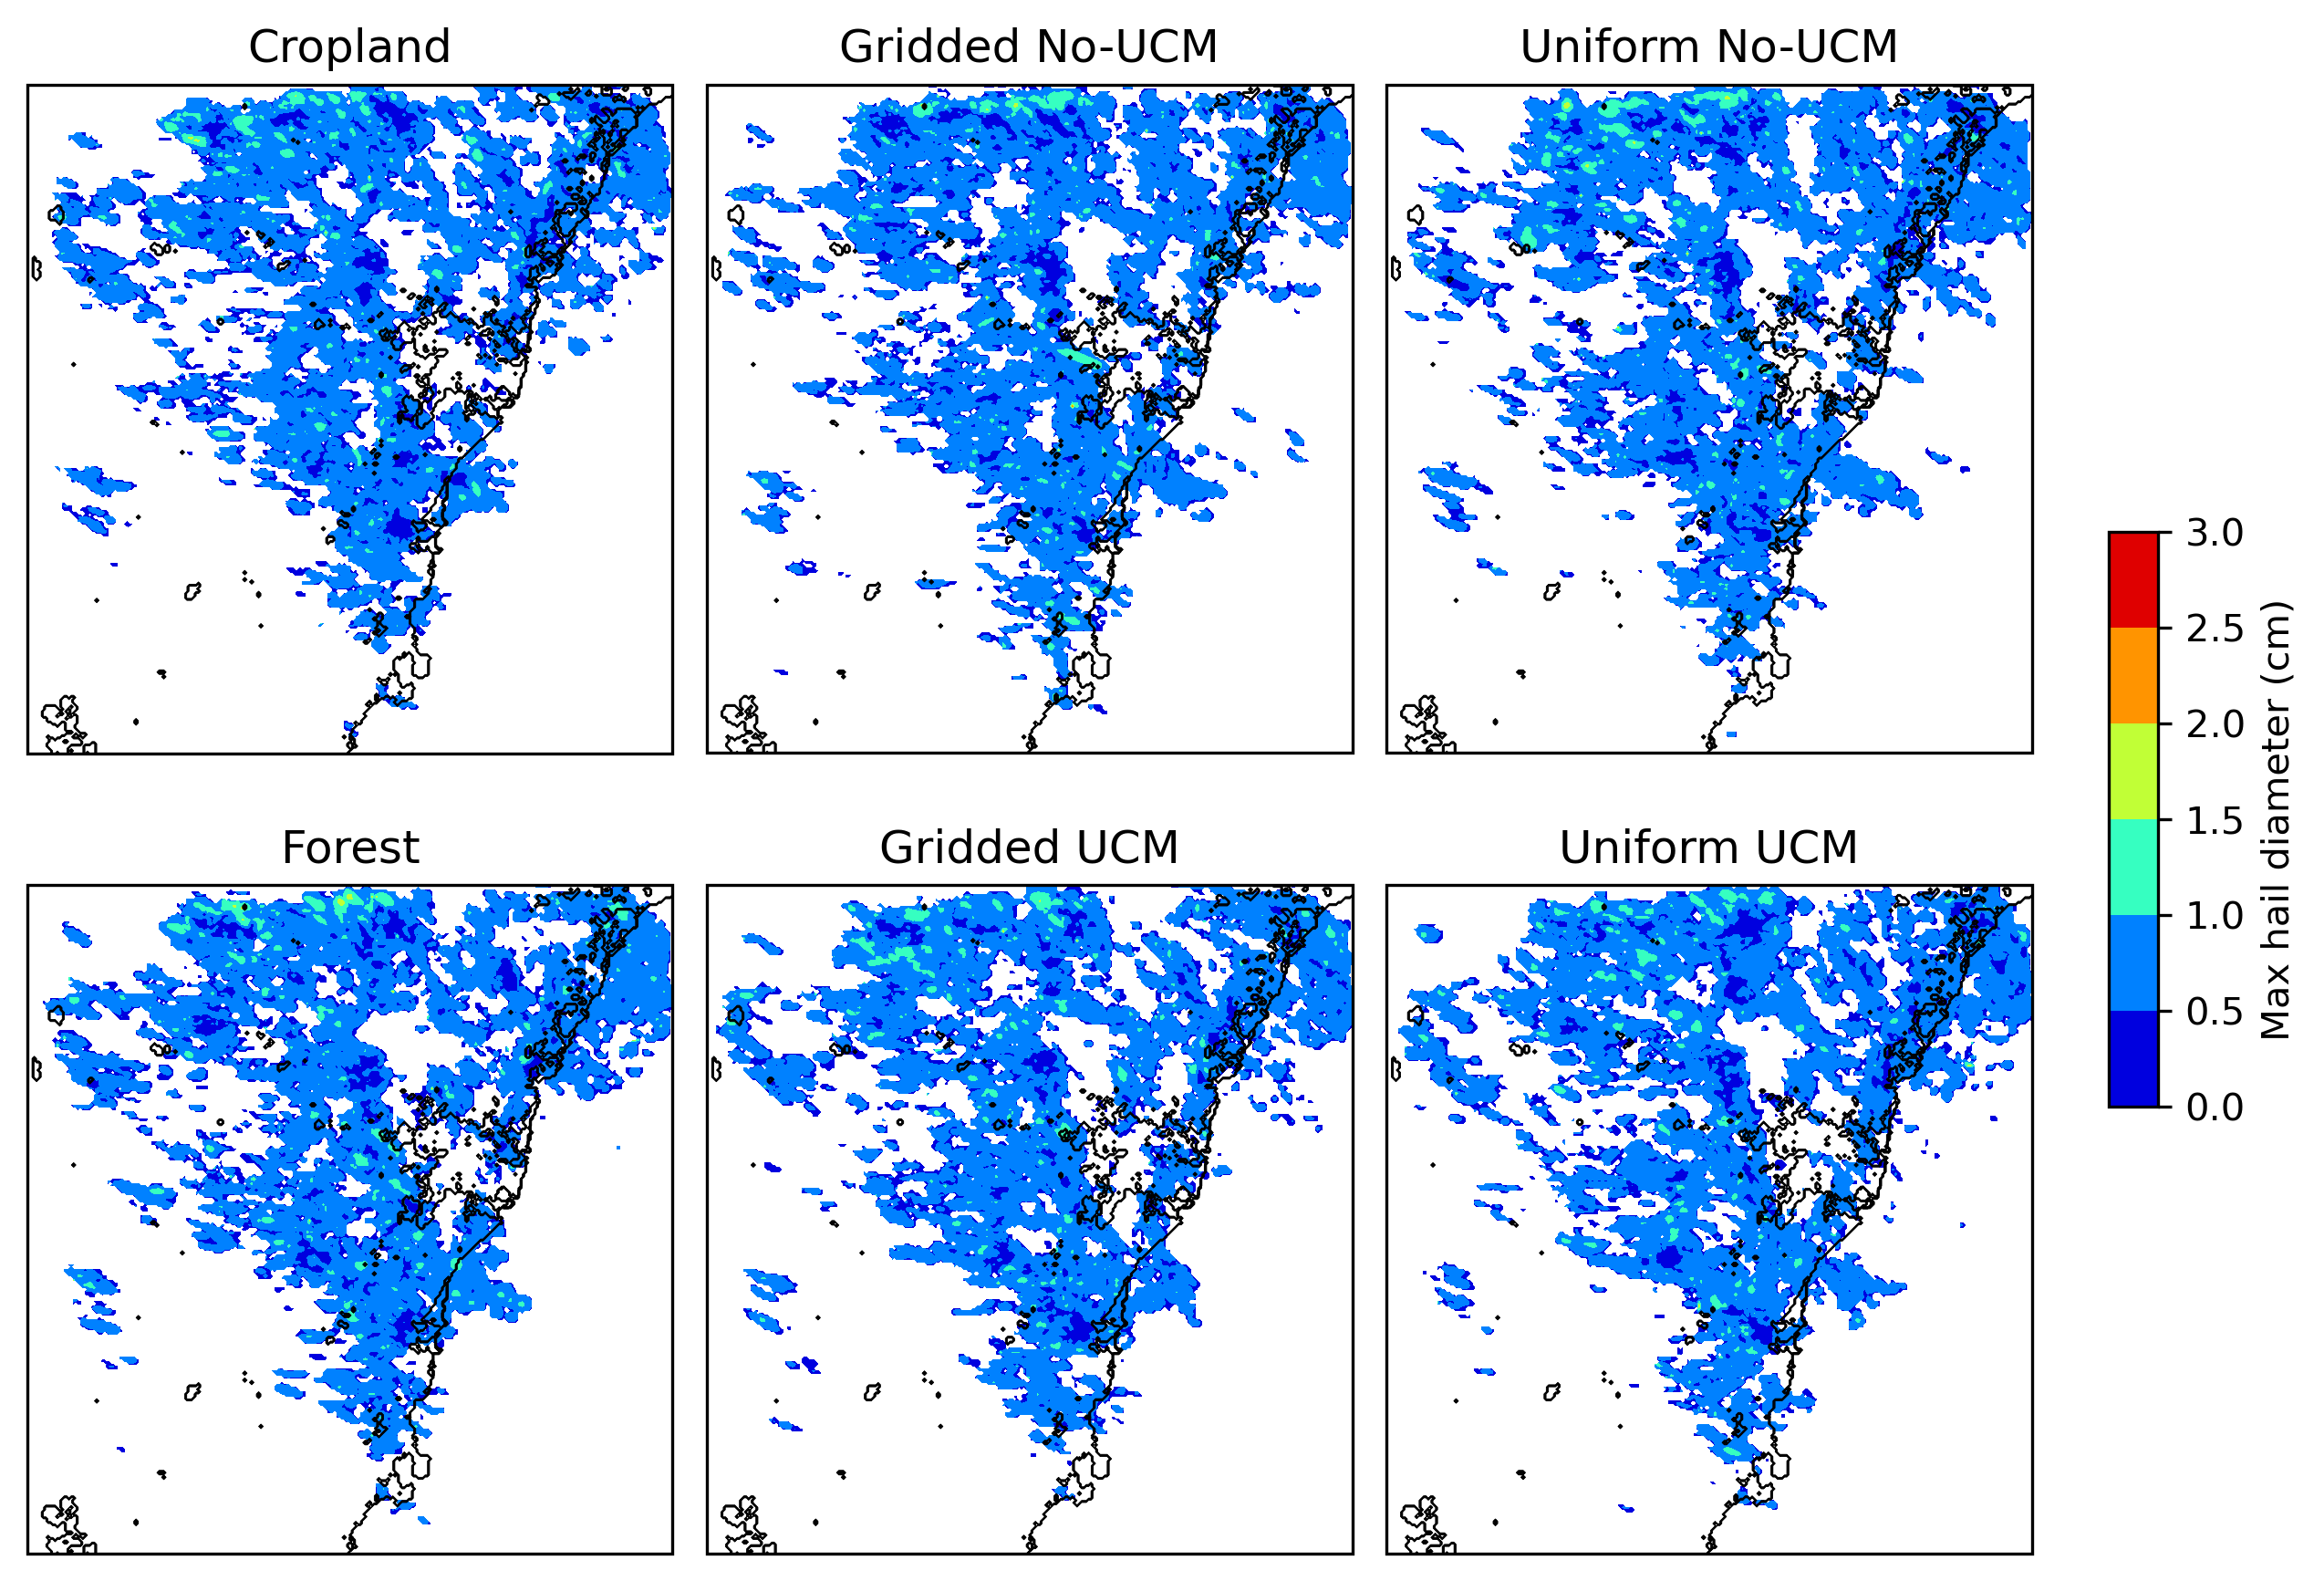

In [11]:
date = '13_2024'

std_crop = np.loadtxt(f'WRF_saved_variables/Stdhail_crop_{date}.txt', dtype=float)
std_nat = np.loadtxt(f'WRF_saved_variables/Stdhail_nat_{date}.txt', dtype=float)
std_gr = np.loadtxt(f'WRF_saved_variables/Stdhail_gr_{date}.txt', dtype=float)
std_grurb = np.loadtxt(f'WRF_saved_variables/Stdhail_grurb_{date}.txt', dtype=float)
std_def = np.loadtxt(f'WRF_saved_variables/Stdhail_def_{date}.txt', dtype=float)
std_defurb = np.loadtxt(f'WRF_saved_variables/Stdhail_defurb_{date}.txt', dtype=float)

en_std = [std_crop, std_gr, std_def, std_nat, std_grurb, std_defurb]
names = ['Cropland', 'Gridded No-UCM', 'Uniform No-UCM', 'Forest', 'Gridded UCM','Uniform UCM' ]

date_dict = {'13_2024':'13/02/2024', '17_2020':'17/12/2020', '18_2017':'18/02/2017', '20_2018':'20/12/2018'}
plot_date = date_dict[date]

max_hail_size = 3

hal = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat') # for metadata

lats, lons = wrf.latlon_coords(hal)
cart_proj = wrf.get_cartopy(hal)

fig = plt.figure(figsize=(12,6), dpi=300)

gs = gridspec.GridSpec(nrows=2, ncols=8, figure=fig)

ax1 = fig.add_subplot(gs[0, 1:3], projection=cart_proj)
ax2 = fig.add_subplot(gs[0, 3:5], projection=cart_proj)
ax3 = fig.add_subplot(gs[0, 5:7], projection=cart_proj)
ax4 = fig.add_subplot(gs[1, 1:3], projection=cart_proj)
ax5 = fig.add_subplot(gs[1, 3:5], projection=cart_proj)
ax6 = fig.add_subplot(gs[1, 5:7], projection=cart_proj)
plt.tight_layout()
axs = [ax1, ax2, ax3, ax4, ax5, ax6]

levels = np.linspace(0, max_hail_size, int(max_hail_size*2+1))

cmapb = (mpl.colors.ListedColormap(['black']))
cmapb.set_bad(alpha=0)
bounds = [49,60]
norm = mpl.colors.BoundaryNorm(bounds, cmapb.N)

for ind in range(len(en_std)):
        hail = en_std[ind]
        hailmask = np.ma.masked_where(hail <= 0, hail)
        nat1 = axs[ind].contourf(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(hailmask), levels = levels, #vmax=5.0,extend='max',
                 transform=crs.PlateCarree(), cmap=plt.colormaps['jet'])
        axs[ind].set_title(names[ind])
        axs[ind].set_xlim(wrf.cartopy_xlim(hal))
        axs[ind].set_ylim(wrf.cartopy_ylim(hal))
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), urb_outline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), gr_coastline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)

fig.subplots_adjust(right=0.83) # position of the right edge of the subplots
cbar_ax = fig.add_axes([0.75, 0.325, 0.015, 0.35]) #left, bottom, width, height
cbar = fig.colorbar(nat1, cax=cbar_ax) #extend = 'max'
cbar.set_label("Max hail diameter (cm)")

# fig.suptitle(f'Standard Deviation in Maximum Surface Hail ({plot_date})', fontsize = 16, fontweight='bold')

### Ensemble-averaged 2 m temperature

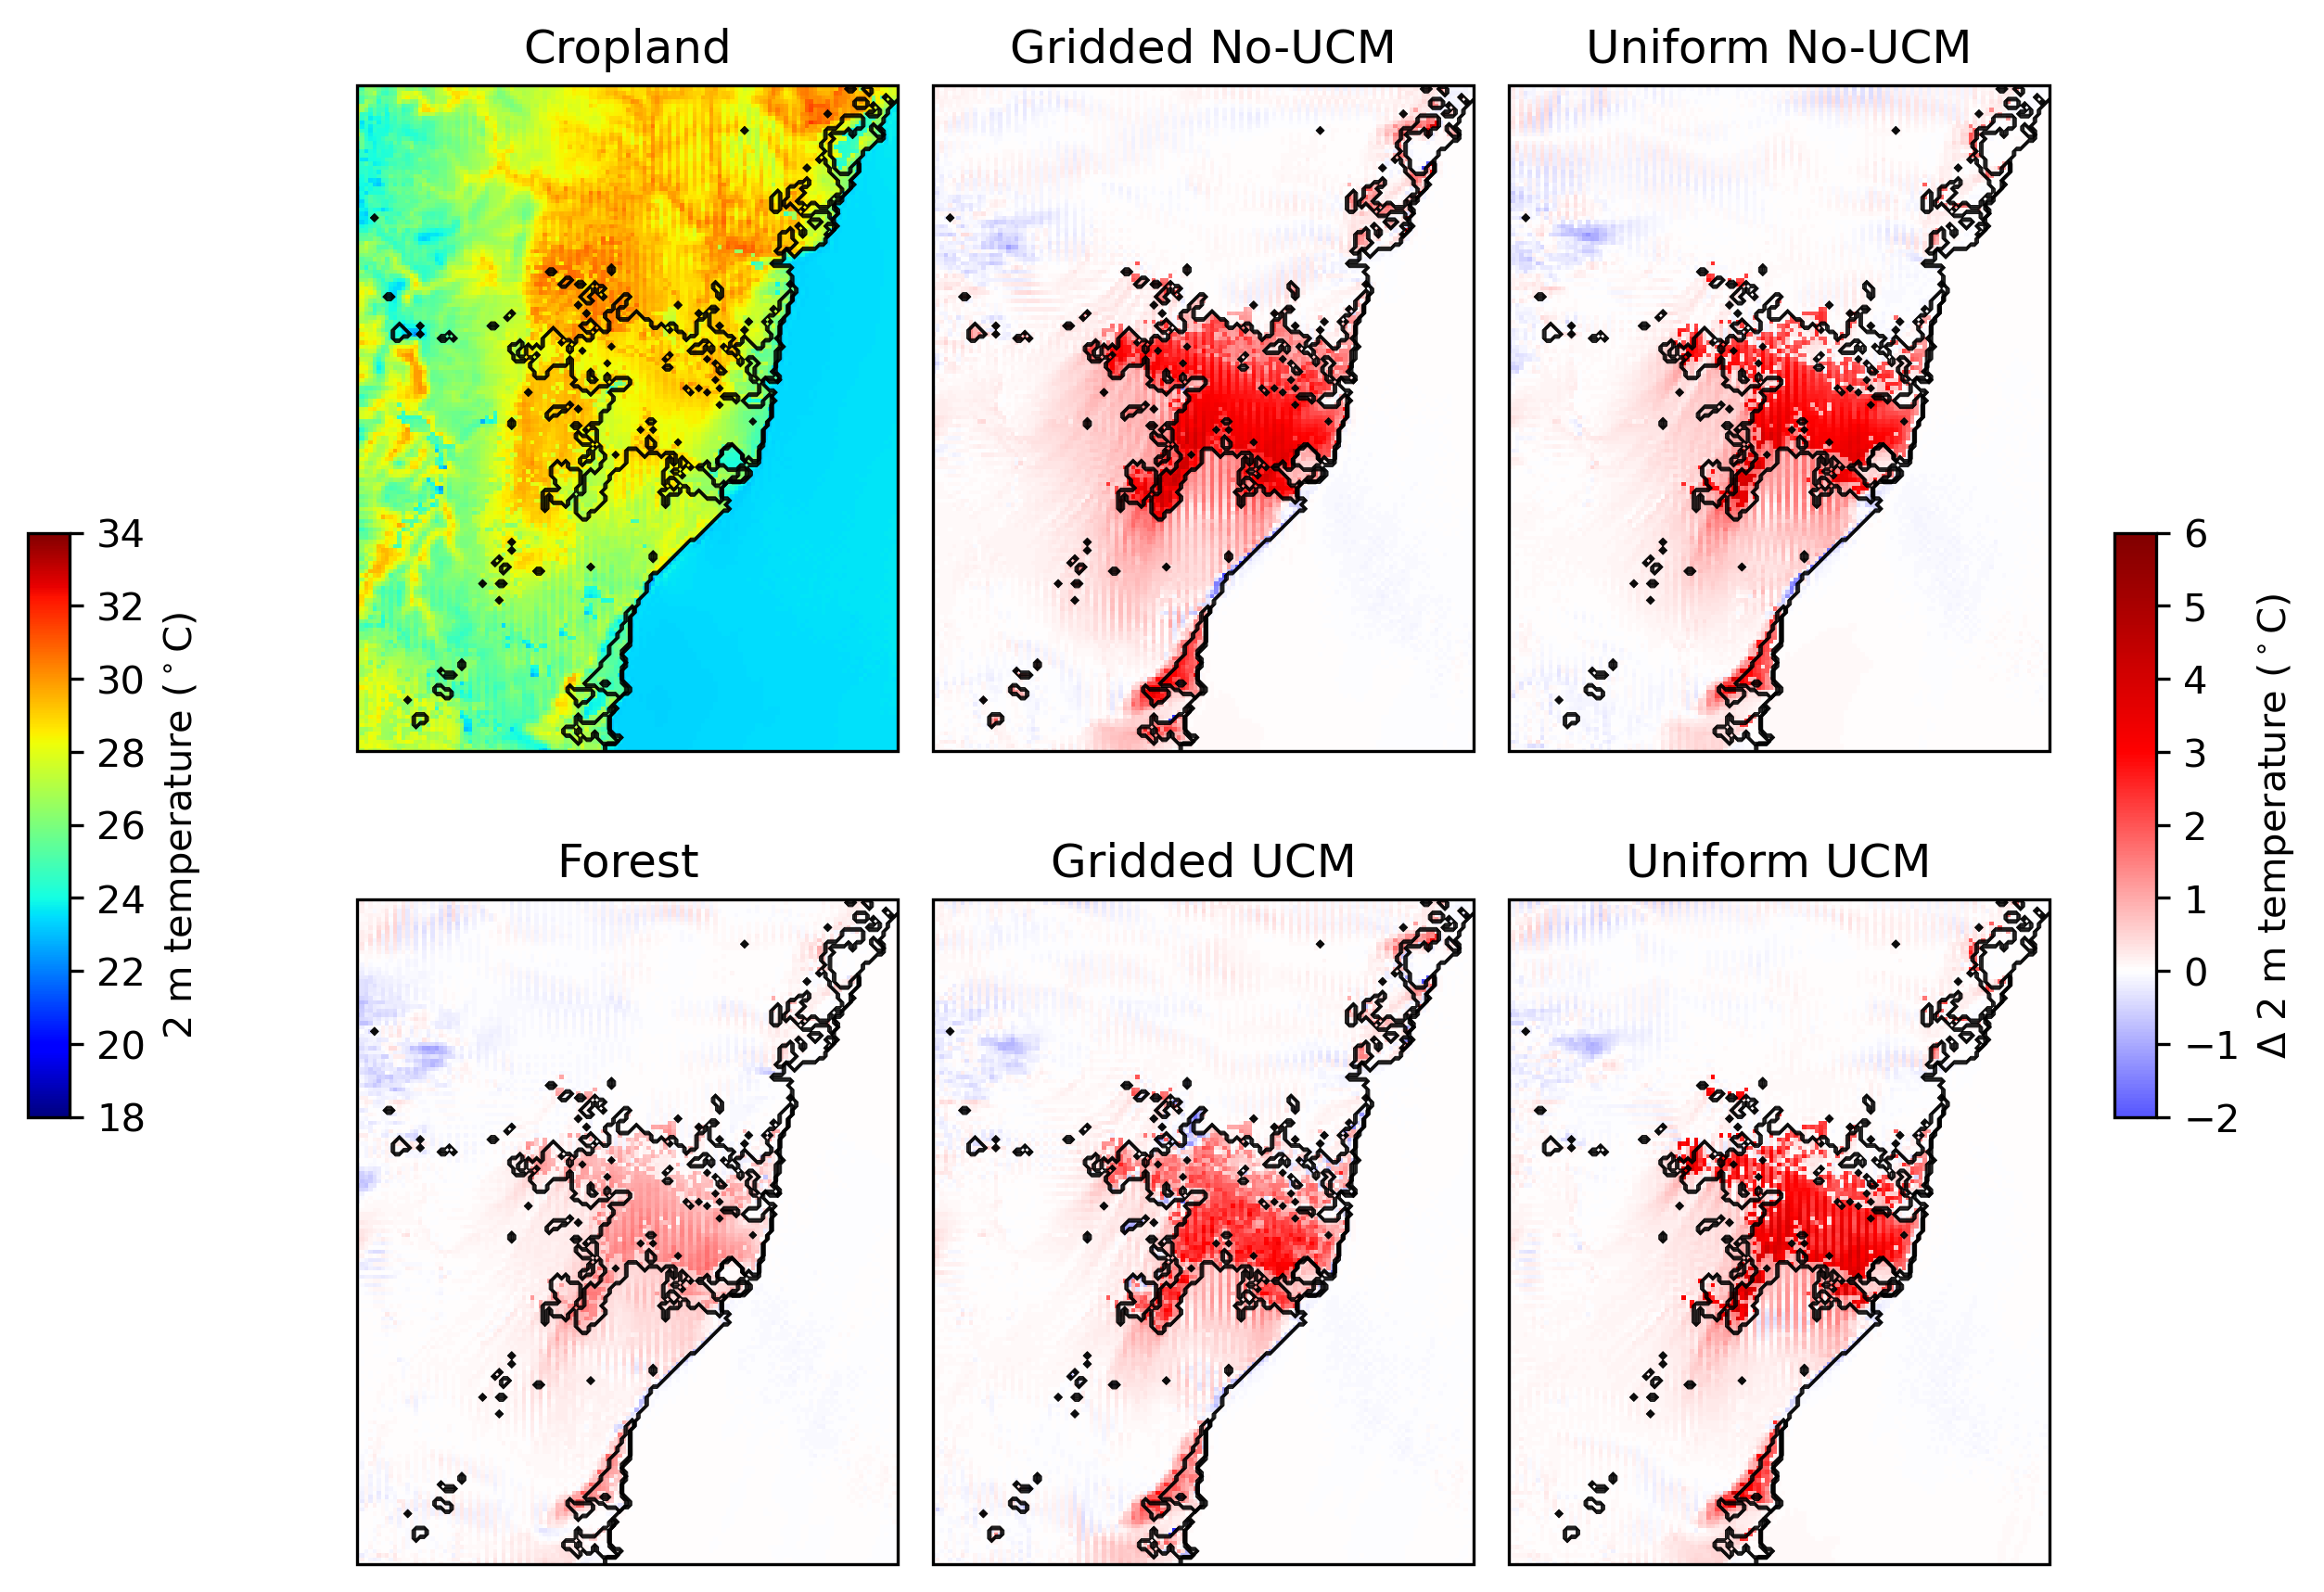

In [13]:
# Making temperature plot
average_crop = xr.open_dataset(f'WRF_saved_variables/Avg_t2_crop_12pm_12_2024.nc')['T2']
average_gr = xr.open_dataset(f'WRF_saved_variables/Avg_t2_gr_12pm_12_2024.nc')['T2']
average_def = xr.open_dataset(f'WRF_saved_variables/Avg_t2_def_12pm_12_2024.nc')['T2']
average_nat = xr.open_dataset(f'WRF_saved_variables/Avg_t2_nat_12pm_12_2024.nc')['T2']
average_grurb = xr.open_dataset(f'WRF_saved_variables/Avg_t2_grurb_12pm_12_2024.nc')['T2']
average_defurb = xr.open_dataset(f'WRF_saved_variables/Avg_t2_defurb_12pm_12_2024.nc')['T2']

temp = [average_crop, average_gr, average_def, average_nat, average_grurb, average_defurb]

names = ['Cropland', 'Gridded No-UCM', 'Uniform No-UCM', 'Forest', 'Gridded UCM','Uniform UCM' ]

hal = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat') # for metadata

lats, lons = wrf.latlon_coords(hal)
cart_proj = wrf.get_cartopy(hal)

fig = plt.figure(figsize=(10,6), dpi=300)

gs = gridspec.GridSpec(nrows=2, ncols=8, figure=fig)

ax1 = fig.add_subplot(gs[0, 1:3], projection=cart_proj)
ax2 = fig.add_subplot(gs[0, 3:5], projection=cart_proj)
ax3 = fig.add_subplot(gs[0, 5:7], projection=cart_proj)
ax4 = fig.add_subplot(gs[1, 1:3], projection=cart_proj)
ax5 = fig.add_subplot(gs[1, 3:5], projection=cart_proj)
ax6 = fig.add_subplot(gs[1, 5:7], projection=cart_proj)
plt.tight_layout()
axs = [ax1, ax2, ax3, ax4, ax5, ax6]

# tlevels = np.linspace(18,34,17)
# difflevels = np.linspace(-2,6,9)

cmapb = (mpl.colors.ListedColormap(['black']))
cmapb.set_bad(alpha=0)
bounds = [49,60]
norm = mpl.colors.BoundaryNorm(bounds, cmapb.N)

norm_plot = TwoSlopeNorm(vmin=-6, vcenter=0, vmax=6)
cmap_seismic = plt.get_cmap('seismic').copy()
cmap_seismic.set_under(color='white')
for ind in range(len(temp)):
        if ind == 0:
                nat1 = axs[ind].pcolormesh(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(temp[ind]),vmin = 18, vmax = 34, #levels = levels, #vmax=5.0,extend='max',
                                           transform=crs.PlateCarree(), cmap=plt.colormaps['jet'], shading='nearest')
        else:
                nat2 = axs[ind].pcolormesh(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(temp[ind])-wrf.to_np(temp[0]),norm=norm_plot, #levels = levels, #vmax=5.0,extend='max',
                                           transform=crs.PlateCarree(), cmap=cmap_seismic, shading='nearest')
        axs[ind].set_title(names[ind])
        axs[ind].set_xlim(wrf.cartopy_xlim(hal))
        axs[ind].set_ylim(wrf.cartopy_ylim(hal))
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), urb_outline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[ind].contour(wrf.to_np(lons), wrf.to_np(lats), gr_coastline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[ind].set_xlim(-10000, 120000)
        axs[ind].set_ylim(-80000, 80000)
fig.subplots_adjust(right=0.83) # position of the right edge of the subplots
cbar_ax = fig.add_axes([0.75, 0.325, 0.015, 0.35]) #left, bottom, width, height
cbar_ax2 = fig.add_axes([0, 0.325, 0.015, 0.35]) #left, bottom, width, height
ticks = [-2,-1,0,1,2,3,4,5,6]
tick2 = [18, 20, 22, 24, 26, 28, 30, 32, 34]
cbar = fig.colorbar(nat2, cax=cbar_ax)
cbar.set_ticks(ticks)
cbar_ax.set_ylim(-2, 6)
cbar2 = fig.colorbar(nat1, cax=cbar_ax2, ticks = tick2)

cbar2.set_label("2 m temperature ($^\circ$C)")
cbar.set_label("$\Delta$ 2 m temperature ($^\circ$C)")

### Ensemble-averaged 10 m wind

In [ ]:
# Selecting time
storm = 2017

date_dict = {2024:'13/02/2024', 2020:'17/12/2020', 2017:'18/02/2017', 2018:'20/12/2018'}

en1 = ensemble_dict[storm][0]
en2 = ensemble_dict[storm][1]
en3 = ensemble_dict[storm][2]
en4 = ensemble_dict[storm][3]
en5 = ensemble_dict[storm][4]

start_date = date_dict[storm][6:]+'-'+date_dict[storm][3:5]+'-'+date_dict[storm][0:2] #local date
start_hour = '12:00:00'   #local time

end_date = date_dict[storm][6:]+'-'+date_dict[storm][3:5]+'-'+str(int(date_dict[storm][0:2])) #local date
end_hour = '13:00:00'   #local time

print(f'Starting at {start_date} and ending at {end_date}')

inds1 = get_indexes(en1,[start_date,start_hour],[end_date,end_hour])
inds2 = get_indexes(en2,[start_date,start_hour],[end_date,end_hour])
inds3 = get_indexes(en3,[start_date,start_hour],[end_date,end_hour])
inds4 = get_indexes(en4,[start_date,start_hour],[end_date,end_hour])
inds5 = get_indexes(en5,[start_date,start_hour],[end_date,end_hour])

# Extract wind data
wind1 = []
u1 = []
v1 = []
wind2 = []
u2 = []
v2 = []
wind3 = []
u3 = []
v3 = []
wind4 = []
u4 = []
v4 = []
wind5 = []
u5 = []
v5 = []

for caseind in range(len(inds1)):
    wind1.append(wrf.g_uvmet.get_uvmet10_wspd_wdir(en1[caseind], timeidx=ALL_TIMES, method='cat')[0,inds1[caseind][0]:inds1[caseind][1]+1,:,:].mean('Time'))
    u1.append(wrf.getvar(en1[caseind], 'U10', timeidx=ALL_TIMES, method='cat')[inds1[caseind][0]:inds1[caseind][1]+1,:,:].mean('Time'))
    v1.append(wrf.getvar(en1[caseind], 'V10', timeidx=ALL_TIMES, method='cat')[inds1[caseind][0]:inds1[caseind][1]+1,:,:].mean('Time'))
    wind2.append(wrf.g_uvmet.get_uvmet10_wspd_wdir(en2[caseind], timeidx=ALL_TIMES, method='cat')[0,inds2[caseind][0]:inds2[caseind][1]+1,:,:].mean('Time'))
    u2.append(wrf.getvar(en2[caseind], 'U10', timeidx=ALL_TIMES, method='cat')[inds2[caseind][0]:inds2[caseind][1]+1,:,:].mean('Time'))
    v2.append(wrf.getvar(en2[caseind], 'V10', timeidx=ALL_TIMES, method='cat')[inds2[caseind][0]:inds2[caseind][1]+1,:,:].mean('Time'))
    wind3.append(wrf.g_uvmet.get_uvmet10_wspd_wdir(en3[caseind], timeidx=ALL_TIMES, method='cat')[0,inds3[caseind][0]:inds3[caseind][1]+1,:,:].mean('Time'))
    u3.append(wrf.getvar(en3[caseind], 'U10', timeidx=ALL_TIMES, method='cat')[inds3[caseind][0]:inds3[caseind][1]+1,:,:].mean('Time'))
    v3.append(wrf.getvar(en3[caseind], 'V10', timeidx=ALL_TIMES, method='cat')[inds3[caseind][0]:inds3[caseind][1]+1,:,:].mean('Time'))
    wind4.append(wrf.g_uvmet.get_uvmet10_wspd_wdir(en4[caseind], timeidx=ALL_TIMES, method='cat')[0,inds4[caseind][0]:inds4[caseind][1]+1,:,:].mean('Time'))
    u4.append(wrf.getvar(en4[caseind], 'U10', timeidx=ALL_TIMES, method='cat')[inds4[caseind][0]:inds4[caseind][1]+1,:,:].mean('Time'))
    v4.append(wrf.getvar(en4[caseind], 'V10', timeidx=ALL_TIMES, method='cat')[inds4[caseind][0]:inds4[caseind][1]+1,:,:].mean('Time'))
    wind5.append(wrf.g_uvmet.get_uvmet10_wspd_wdir(en5[caseind], timeidx=ALL_TIMES, method='cat')[0,inds5[caseind][0]:inds5[caseind][1]+1,:,:].mean('Time'))
    u5.append(wrf.getvar(en5[caseind], 'U10', timeidx=ALL_TIMES, method='cat')[inds5[caseind][0]:inds5[caseind][1]+1,:,:].mean('Time'))
    v5.append(wrf.getvar(en5[caseind], 'V10', timeidx=ALL_TIMES, method='cat')[inds5[caseind][0]:inds5[caseind][1]+1,:,:].mean('Time'))
wind = []
u = []
v = []
for i in range(len(wind1)):
    a = (wind1[i]+wind2[i]+wind3[i]+wind4[i]+wind5[i])/5
    wind.append(a)
    b = (v1[i]+v2[i]+v3[i]+v4[i]+v5[i])/5
    v.append(b)
    c = (u1[i]+u2[i]+u3[i]+u4[i]+u5[i])/5
    u.append(c)


Starting at 2024-02-12 and ending at 2024-02-12


In [ ]:
# Making wind speed plot
names = ['Cropland', 'Forest', 'Gridded No-UCM', 'Gridded UCM', 'Uniform No-UCM', 'Uniform UCM' ]
heat_flux = []
hal = wrf.getvar(grid, 'LU_INDEX', timeidx=0, method='cat') # for metadata

lats, lons = wrf.latlon_coords(hal)
cart_proj = wrf.get_cartopy(hal)

fig = plt.figure(figsize=(10,6), dpi=300)

gs = gridspec.GridSpec(nrows=2, ncols=8, figure=fig)

ax1 = fig.add_subplot(gs[0, 1:3], projection=cart_proj)
ax2 = fig.add_subplot(gs[0, 3:5], projection=cart_proj)
ax3 = fig.add_subplot(gs[0, 5:7], projection=cart_proj)
ax4 = fig.add_subplot(gs[1, 1:3], projection=cart_proj)
ax5 = fig.add_subplot(gs[1, 3:5], projection=cart_proj)
ax6 = fig.add_subplot(gs[1, 5:7], projection=cart_proj)
plt.tight_layout()
axs = [ax1, ax2, ax3, ax4, ax5, ax6]

plot_order = [0,2,4,1,3,5]

cmapb = (mpl.colors.ListedColormap(['black']))
cmapb.set_bad(alpha=0)
bounds = [49,60]
norm = mpl.colors.BoundaryNorm(bounds, cmapb.N)
levels = np.linspace(0,14,15)
levels2 = np.linspace(-7,7,15)


norm_plot = TwoSlopeNorm(vmin=-7, vcenter=0, vmax=7)
cmap_seismic = plt.get_cmap('coolwarm').copy()
cmap_seismic.set_under(color='white')

i = 0

for ind in plot_order:
        if ind == 0:
                nat1 = axs[i].contourf(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(wind[ind]),
                                           transform=crs.PlateCarree(), cmap=plt.colormaps['jet'], levels= levels)
                axs[i].quiver(to_np(lons[::10, ::10]), to_np(lats[::10, ::10]),
                          to_np(u[ind][::10, ::10]), to_np(v[ind][::10, ::10]), transform=crs.PlateCarree())
        else:
                nat2 = axs[i].contourf(wrf.to_np(lons), wrf.to_np(lats), wrf.to_np(wind[ind])-wrf.to_np(wind[0]),
                                           transform=crs.PlateCarree(), cmap=cmap_seismic, norm = norm_plot, levels=levels2, 
                                           alpha = 0.9)
                udiff = u[ind] - u[0]
                vdiff = v[ind] - v[0]
                axs[i].quiver(to_np(lons[::10, ::10]), to_np(lats[::10, ::10]),
                          to_np(udiff[::10, ::10]), to_np(vdiff[::10, ::10]), transform=crs.PlateCarree())
        axs[i].set_title(names[ind])
        axs[i].set_xlim(wrf.cartopy_xlim(hal))
        axs[i].set_ylim(wrf.cartopy_ylim(hal))
        axs[i].contour(wrf.to_np(lons), wrf.to_np(lats), urb_outline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[i].contour(wrf.to_np(lons), wrf.to_np(lats), gr_coastline(), 
                transform=crs.PlateCarree(), cmap=cmapb, linewidths = 0.2)
        axs[i].set_xlim(-10000, 120000)
        axs[i].set_ylim(-80000, 80000)
        i = i+1
fig.subplots_adjust(right=0.83) # position of the right edge of the subplots
cbar_ax = fig.add_axes([0.75, 0.325, 0.015, 0.41]) #left, bottom, width, height
cbar_ax2 = fig.add_axes([0.02, 0.6, 0.015, 0.3]) #left, bottom, width, height
ticks = [-7,-6,-5,-4,-3,-2,-1,0,1,2,3]
tick2 = [0,1,2,3,4,5,6,7,8,9,10,11]
cbar = fig.colorbar(nat2, cax=cbar_ax)
cbar.set_ticks(ticks)
cbar_ax.set_ylim(-7, 3)
cbar2 = fig.colorbar(nat1, cax=cbar_ax2, ticks = tick2) 
cbar2.set_label("Wind speed (m/s)")
cbar.set_label("$\Delta$ Wind speed (m/s)")

### Figure plots from standard deviation and average plots

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

font = FontProperties(family='Times New Roman')
image_paths = ['/home/561/em3807/honours-project/Thesis code/Average hail 2024.png', '/home/561/em3807/honours-project/Thesis code/Standard dev 2024.png']
sub_labels = ['a', 'b']
sub_text = ['Ensemble average', 'Ensemble standard deviation']

fig, axd = plt.subplot_mosaic([['img1'], ['img2']], 
                              figsize=(10, 12), dpi=300)

mosaic_keys = ['img1', 'img2']

for i, key in enumerate(mosaic_keys):
    ax = axd[key]
    img = mpimg.imread(image_paths[i])
    ax.imshow(img)
    ax.axis('off')

    full_label = f"({sub_labels[i]}) {sub_text[i]}"
    ax.text(0.5, -0.05, full_label, transform=ax.transAxes, 
            fontsize=13, va='top', ha='center',fontproperties=font)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()